In [43]:
#here lets see how to make a parallel workflow in the langgraph ``

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv  
from langchain_groq import ChatGroq 
from typing import TypedDict
from langchain.prompts import PromptTemplate 


In [44]:
# input(runs,balls, 4s,6s ) and then we have to return output(S.R.,balls_per_boundry,boundry_percentage)
# and we have to return summary of this 
# and these above 3 calculation works in a parallel manner so it will work fast 

In [45]:
#lets define the state 
class Player_state(TypedDict):
    runs: int 
    balls: int 
    no_of_4s: int 
    no_of_6s: int 
    strike_rate: float 
    balls_per_boundry: float 
    boundary_percentage: float 
    summary: str #here we return all of the content in as a english string 
    

In [46]:
# now lets make logic function for nodes 
def strike_rate_calculator(state: Player_state)-> Player_state:
    balls=state['balls']
    runs=state['runs']
    strike_rate=runs/balls*100
    # state['strike_rate']=round(strike_rate,2) 
    # return state it is a parallel workflow so we have to return only the updated values 
    return {'strike_rate':round(strike_rate,2)} #paritial update in the state 


def boundry_percentage_calculator(state: Player_state)-> Player_state:
    runs=state['runs']
    fours=state['no_of_4s']
    sixes=state['no_of_6s']
    boundary_runs=(fours*4)+(sixes*6)
    boundary_percent=(boundary_runs/runs)*100 
    # state['boundary_percentage']=boundary_percent
    return {'boundary_percentage':round(boundary_percent,2)}

def ball_per_boundary_calculator(state: Player_state)-> Player_state:
    balls=state['balls'] 
    fours=state['no_of_4s']
    sixes=state['no_of_6s']
    total_boundaries=sixes+fours 
    ball_per_boundary=balls/total_boundaries 
    # state['balls_per_boundry']=ball_per_boundary
    return {'balls_per_boundry':round(ball_per_boundary,2)}



In [47]:
#lets make a summary function that create the summary of our stats 
def summarizer(state: Player_state)-> Player_state: 
    balls=state['balls'] 
    runs=state['runs']
    fours=state['no_of_4s']
    sixes=state['no_of_6s']
    balls_per_boundary=state['balls_per_boundry']
    boundary_percent=state['boundary_percentage']
    strike_rate=state['strike_rate']
    summary=f'''
                Total balls faced : {balls} \n 
                Total runs scored : {runs} \n
                Total 4's : {fours} \n
                Total 6's : {sixes} \n 
                Strike rate : {strike_rate} \n 
                Boundary Percentage : {boundary_percent} \n 
                Balls per Boundary : {balls_per_boundary} '''

    state['summary']=summary
    return state     

In [48]:
#our all the 4 function are ready lets make a graph for it 
graph=StateGraph(Player_state) 


#lets add nodes 
graph.add_node('strike_rate_calculator',strike_rate_calculator)
graph.add_node('balls_per_boundary_calculator',ball_per_boundary_calculator)
graph.add_node('summarizer',summarizer)
graph.add_node('boundary_percentage_calculator',boundry_percentage_calculator)


#lets make edges 
graph.add_edge(START,'strike_rate_calculator')
graph.add_edge(START,'balls_per_boundary_calculator')
graph.add_edge(START,'boundary_percentage_calculator')
graph.add_edge('strike_rate_calculator','summarizer')
graph.add_edge('balls_per_boundary_calculator','summarizer')
graph.add_edge('boundary_percentage_calculator','summarizer')

#last edge 
graph.add_edge('summarizer',END)





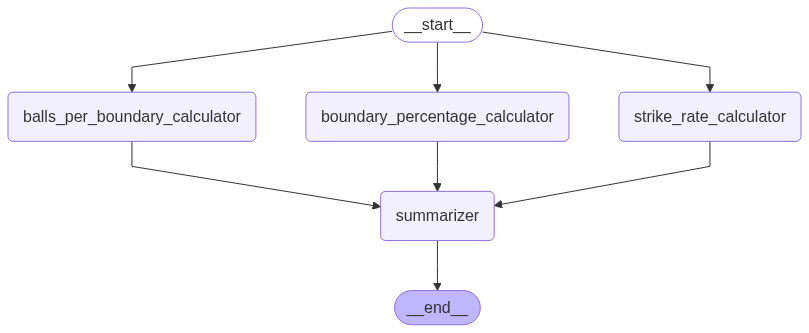

In [49]:
#lets compile it and see our graph workflow 
workflow=graph.compile()
workflow #here we can see our workflow represented as a graph 
#but sometimes it returned error when you print it so try again 

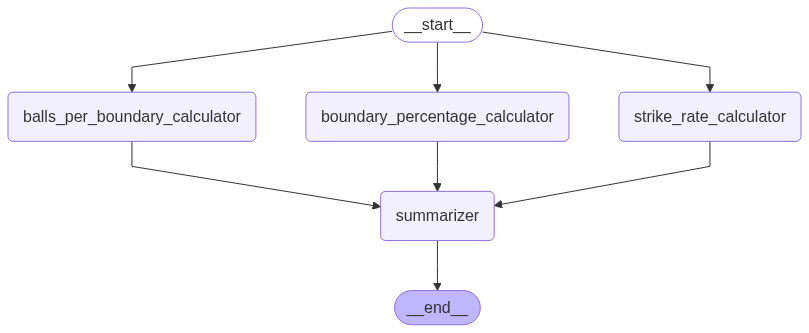

In [50]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [51]:
#lets invoke our workflow and collect the output from it 
# initial_state={'balls':80,'runs':158,'no_of_4s':15,'no_of_6s':10}
initial_state={'runs':100,'balls':50,'no_of_4s':6,'no_of_6s':4}
final_state=workflow.invoke(initial_state) #we have to provide it our initial state 
#but doint this directly it causes an error 
#so we have to handle it because it is a parallel workflows 

#to handling the error instead of returning the whole state from a node 
#we return only the updated content from the node 
print(final_state)

{'runs': 100, 'balls': 50, 'no_of_4s': 6, 'no_of_6s': 4, 'strike_rate': 200.0, 'balls_per_boundry': 5.0, 'boundary_percentage': 48.0, 'summary': "\n                Total balls faced : 50 \n \n                Total runs scored : 100 \n\n                Total 4's : 6 \n\n                Total 6's : 4 \n \n                Strike rate : 200.0 \n \n                Boundary Percentage : 48.0 \n \n                Balls per Boundary : 5.0 "}


In [52]:
#lets only print the summary that we have made after the calculations 
final_state['summary']
from IPython.display import display,Markdown  
display(Markdown(final_state['summary'])) #for the formatted output 



                Total balls faced : 50 
 
                Total runs scored : 100 

                Total 4's : 6 

                Total 6's : 4 
 
                Strike rate : 200.0 
 
                Boundary Percentage : 48.0 
 
                Balls per Boundary : 5.0 